In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv('./data/insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1
...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1,10600.54830,0
1334,18,0,31.920,0,0,0,2205.98080,1
1335,18,0,36.850,0,0,2,1629.83350,1
1336,21,0,25.800,0,0,3,2007.94500,0


<AxesSubplot:>

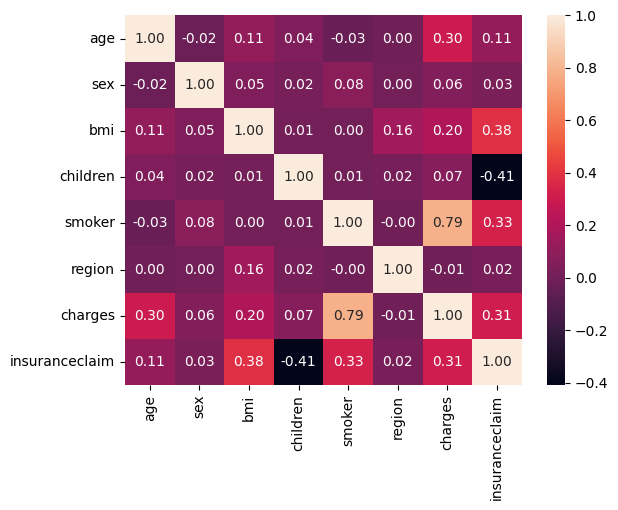

In [3]:
sns.heatmap(df.corr(), annot=True, fmt='.2f')

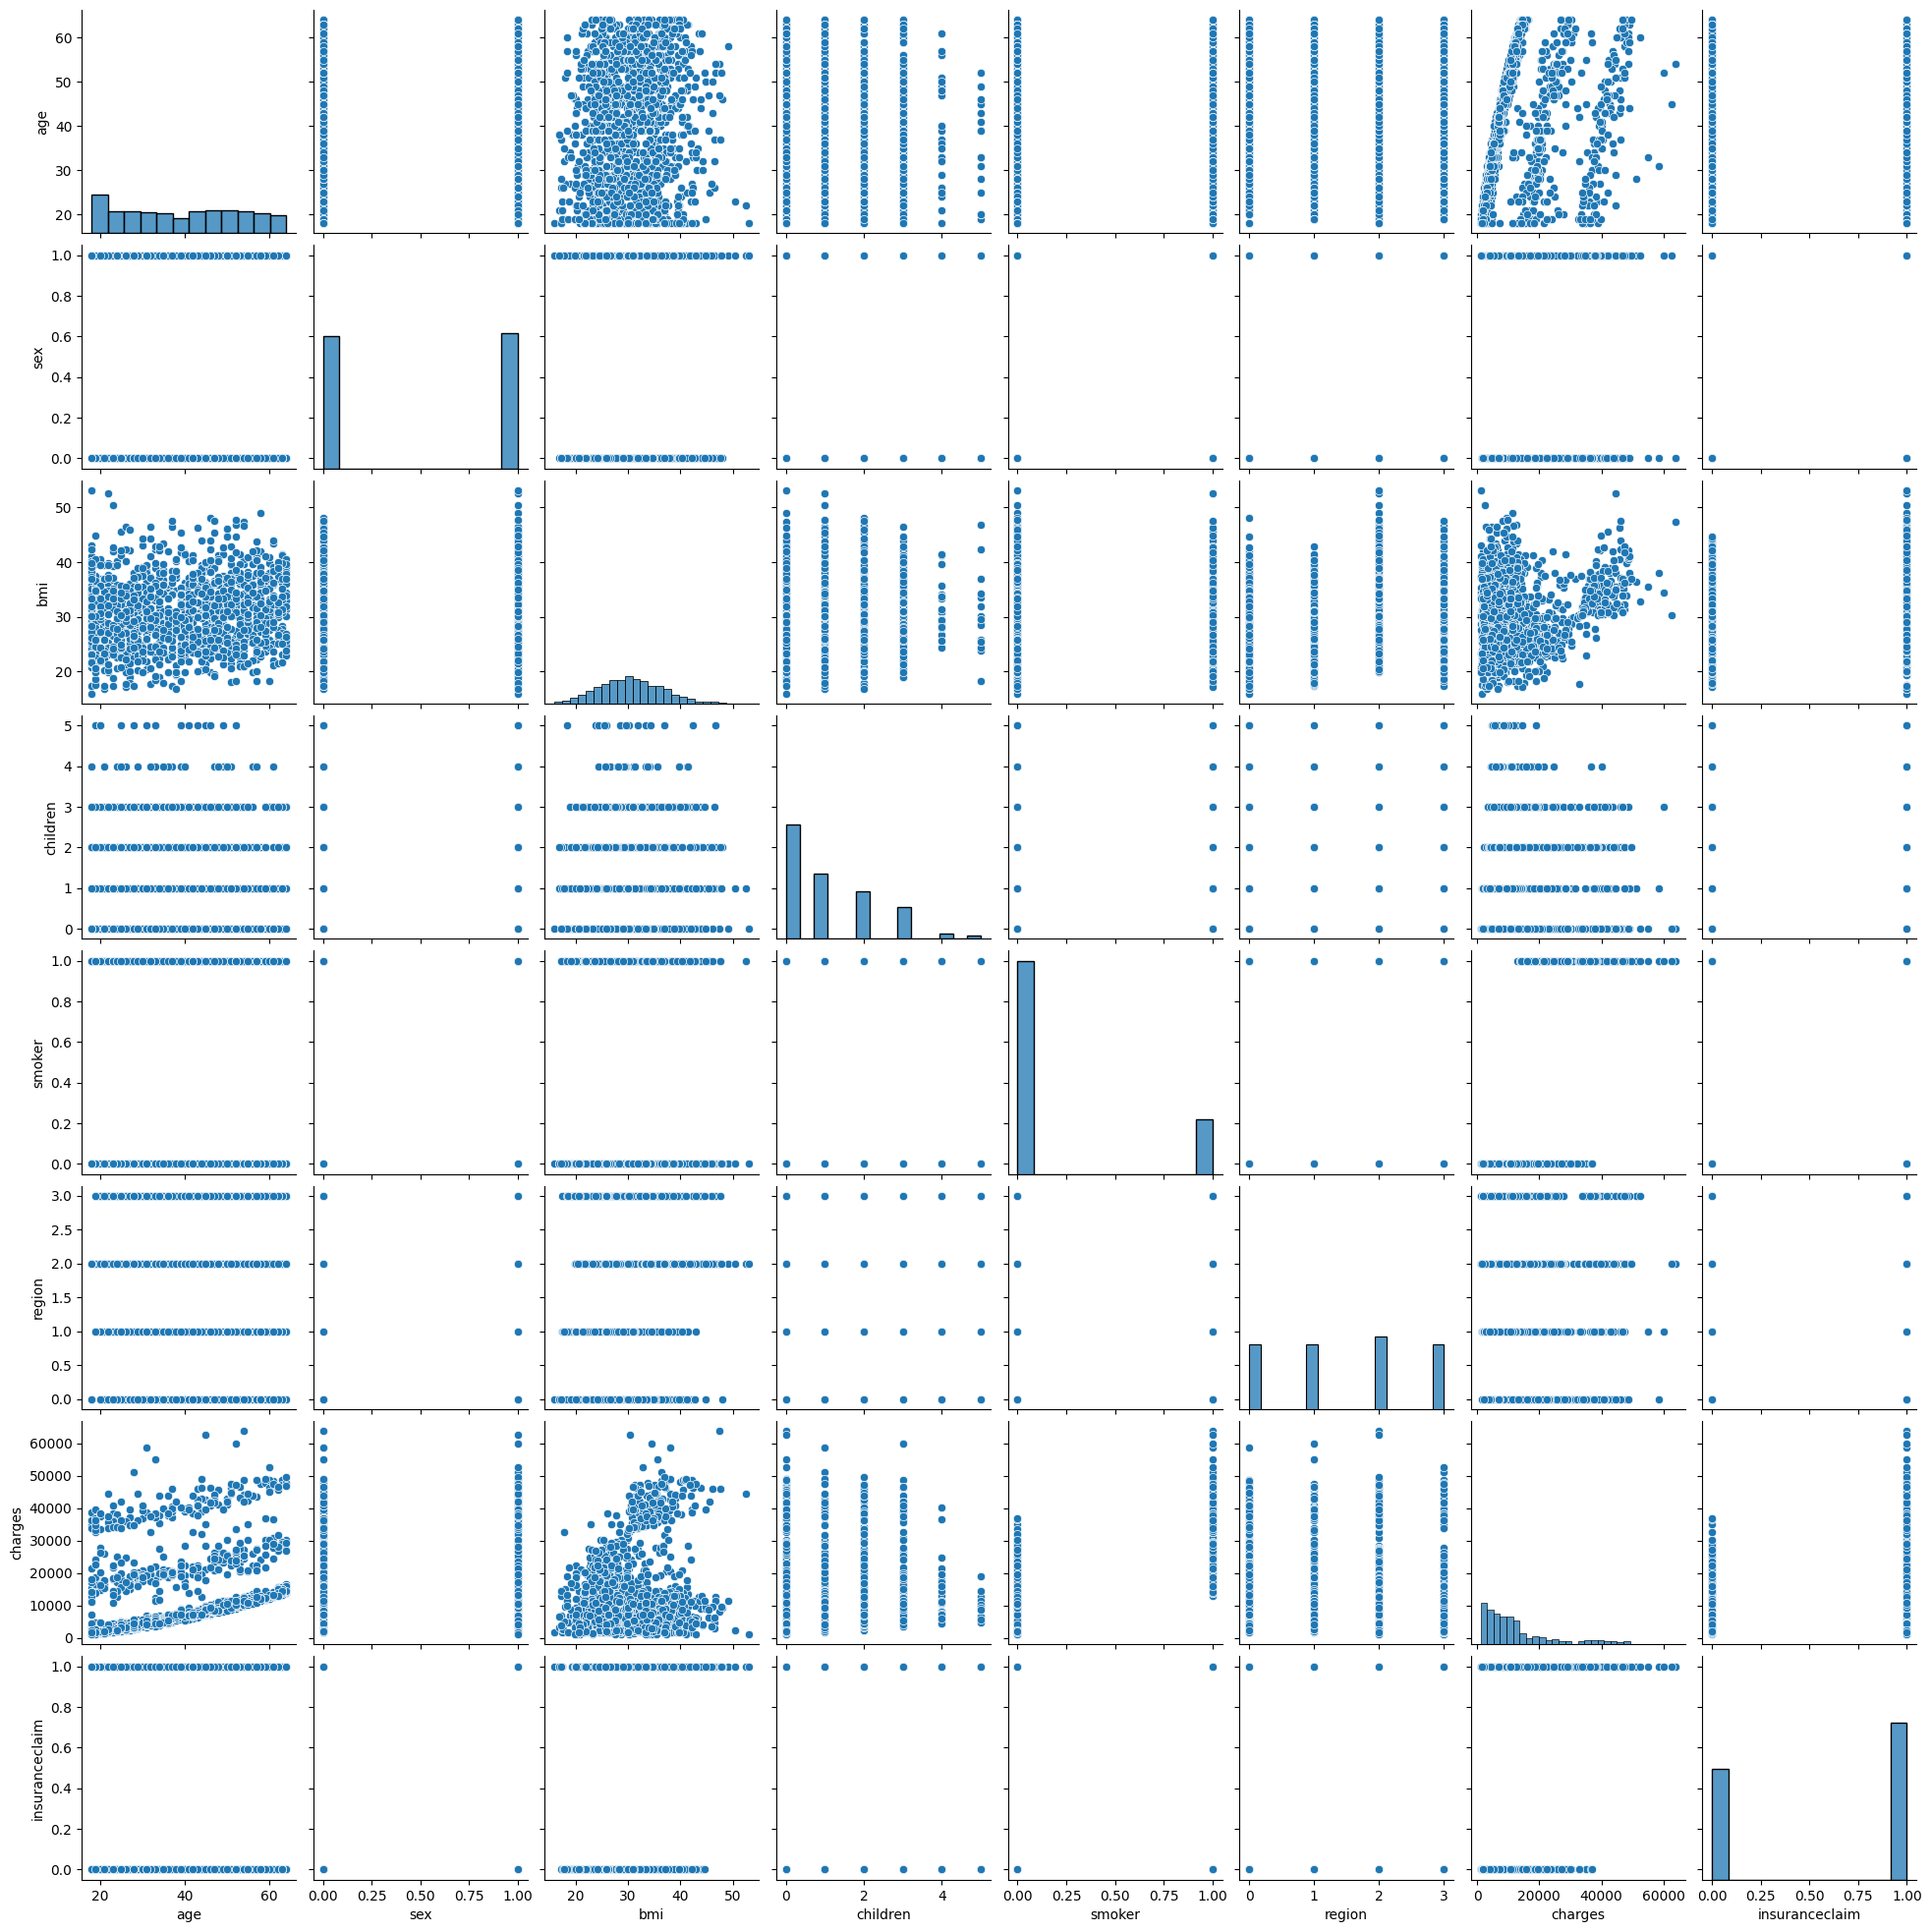

In [4]:
sns.pairplot(df)

# Linear Regression

In [5]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_feature = 'age'
y_feature = 'charges'

x = x_scaler.fit_transform(df[[x_feature]])
y = y_scaler.fit_transform(df[[y_feature]])

(x_train, x_test, y_train, y_test) = train_test_split(x, y, test_size=0.15, random_state=42)

In [6]:
linreg_model = LinearRegression()
linreg_model.fit(x_train, y_train)
linreg_model

LinearRegression()

In [7]:
y_pred = linreg_model.predict(x_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

x_test_original = x_scaler.inverse_transform(x_test)
y_pred_original = y_scaler.inverse_transform(y_pred)

print(f"Model Intercept: {linreg_model.intercept_[0]:.5f}")
print(f"Model Coefficient (Slope): {linreg_model.coef_[0][0]:.5f}")
print(f"Mean Squared Error (MSE) on Test Data: {mse:.2f}")
print(f"R-squared (R²) Score on Test Data: {r2:.2f}")

Model Intercept: 0.00038
Model Coefficient (Slope): 0.28428
Mean Squared Error (MSE) on Test Data: 0.90
R-squared (R²) Score on Test Data: 0.13


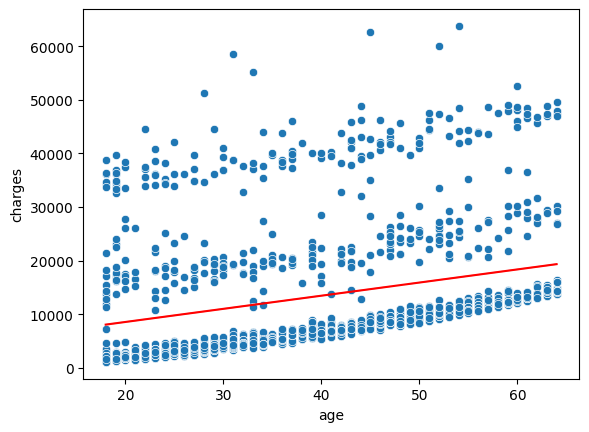

In [8]:
sns.scatterplot(df, x=x_feature, y=y_feature)
sns.lineplot(pd.DataFrame({x_feature: x_test_original.flatten(), y_feature: y_pred_original.flatten()}), x=x_feature, y=y_feature, color='red')
plt.show()

# Decision Tree

In [9]:
features = ['children', 'bmi', 'smoker', 'age']

X = df[features]
y = df['insuranceclaim']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.15, 
    random_state=42
)

In [10]:
dtree_model = DecisionTreeClassifier(random_state=42, criterion='gini')
dtree_entropy_model = DecisionTreeClassifier(random_state=42, criterion='entropy')

dtree_model.fit(X_train, y_train)
dtree_entropy_model.fit(X_train, y_train)

dtree_model

DecisionTreeClassifier(random_state=42)

In [11]:
dt_pred = dtree_model.predict(X_test)

result = X_test.copy(deep=True)
result['insuranceclaim'] = y_test
result['insuranceclaim (prediction)'] = dt_pred

result

,children,bmi,smoker,age,insuranceclaim,insuranceclaim (prediction)
764,2,25.175,0,45,1,0
887,0,30.020,0,36,1,1
890,0,26.885,1,64,1,1
1293,3,25.745,0,46,1,1
259,0,31.920,1,19,1,1
...,...,...,...,...,...,...
636,1,24.510,0,19,0,0
1073,2,28.880,0,54,1,1
31,0,26.315,0,18,1,1
351,0,25.600,0,50,0,0


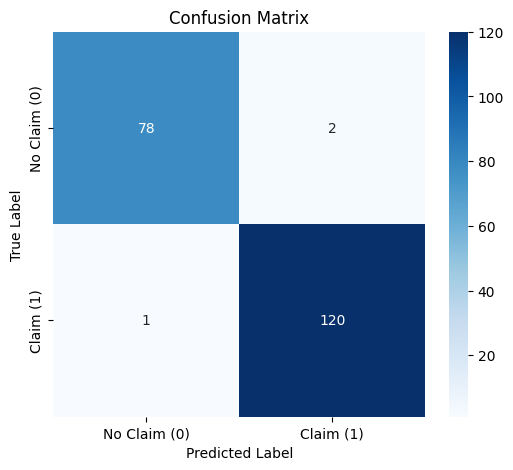

In [12]:
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Claim (0)', 'Claim (1)'],
            yticklabels=['No Claim (0)', 'Claim (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [13]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98        80
           1       0.98      0.99      0.99       121

    accuracy                           0.99       201
   macro avg       0.99      0.98      0.98       201
weighted avg       0.99      0.99      0.99       201



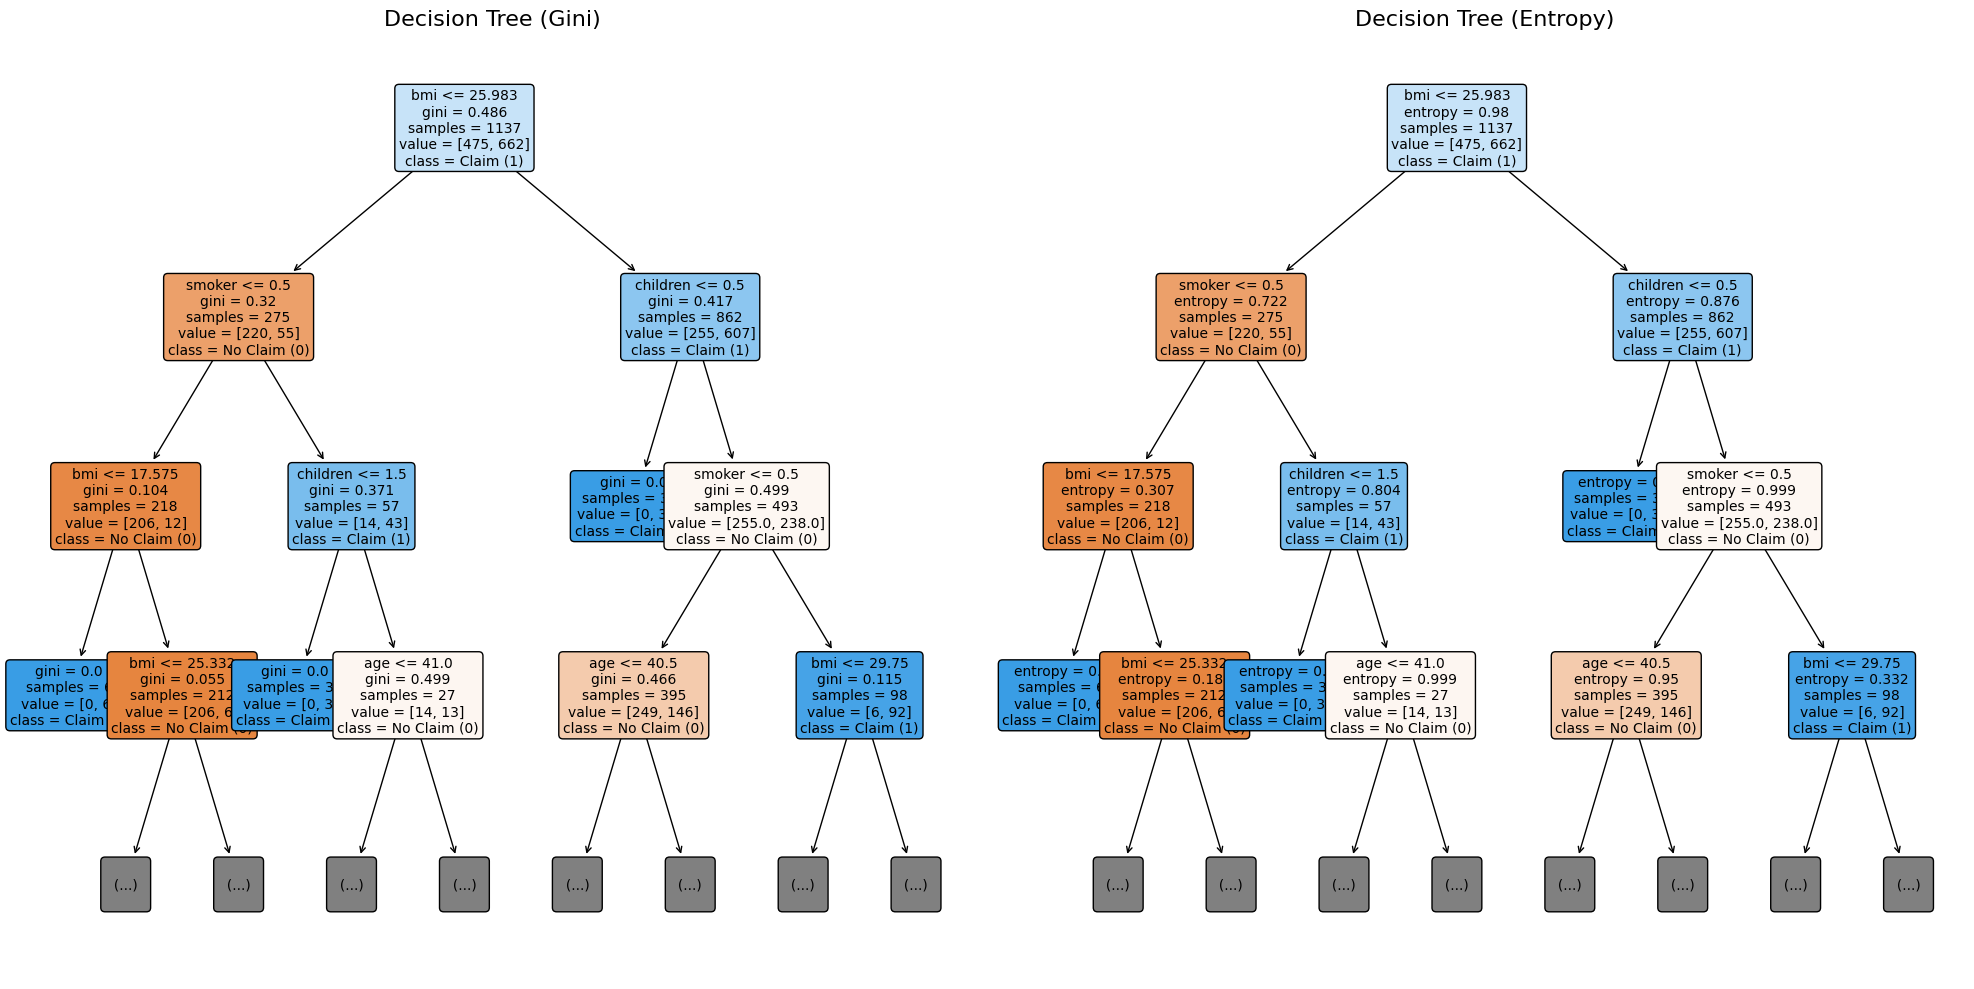

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))

plot_tree(
    dtree_model, 
	feature_names=features,  
	class_names=['No Claim (0)', 'Claim (1)'],
	filled=True, 
	rounded=True, 
	max_depth=3,
	fontsize=10,
	ax=axes[0]
)

plot_tree(
	dtree_entropy_model, 
	feature_names=features,  
	class_names=['No Claim (0)', 'Claim (1)'],
	filled=True, 
	rounded=True, 
	max_depth=3,
	fontsize=10,
	ax=axes[1]
)

axes[0].set_title("Decision Tree (Gini)", fontsize=16)
axes[1].set_title("Decision Tree (Entropy)", fontsize=16)

plt.tight_layout()
plt.show()

# Random Forest Classifier

In [15]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_model

RandomForestClassifier(random_state=42)

In [16]:
rf_pred = rf_model.predict(X_test)

result = X_test.copy(deep=True)
result['insuranceclaim'] = y_test
result['insuranceclaim (prediction)'] = rf_pred

result

,children,bmi,smoker,age,insuranceclaim,insuranceclaim (prediction)
764,2,25.175,0,45,1,0
887,0,30.020,0,36,1,1
890,0,26.885,1,64,1,1
1293,3,25.745,0,46,1,1
259,0,31.920,1,19,1,1
...,...,...,...,...,...,...
636,1,24.510,0,19,0,0
1073,2,28.880,0,54,1,1
31,0,26.315,0,18,1,1
351,0,25.600,0,50,0,0


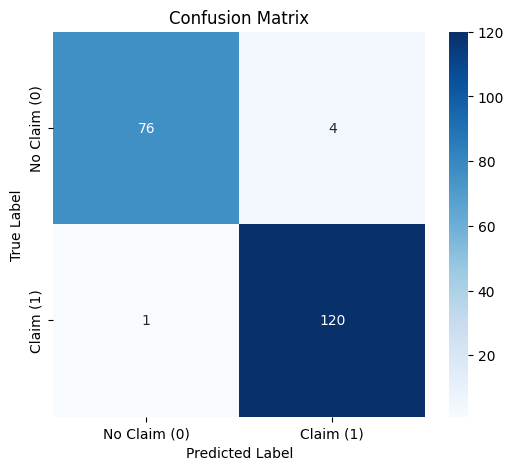

In [17]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Claim (0)', 'Claim (1)'],
            yticklabels=['No Claim (0)', 'Claim (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [18]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98        80
           1       0.98      0.99      0.99       121

    accuracy                           0.99       201
   macro avg       0.99      0.98      0.98       201
weighted avg       0.99      0.99      0.99       201

